# Check the absolute normalization

In [1]:
%load_ext autoreload
%autoreload 

In [2]:
import pandas as pd
import numpy as np
from os import path, makedirs
from datetime import datetime
from tqdm import tqdm

# local imports
import sys
sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana') # absolute path for running on EAF
from pyanalib.split_df_helpers import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.constants import *
from analysis_village.numucc_1p0pi.files_config import *
from pyanalib.covariance import *
from makedf.mcstat import get_MCstat_unc

# turn off PerformanceWarning 
# triggered by mismatched column levels
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

mc_n_split: 1
mc_tot_pot: 1.521e+19
Integrated flux: 2.456e+11
# of targets:  1.3251484770937053e+30
XSEC_UNIT is 0, setting to 1e-38
xsec unit:  1e-38


/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/notebooks/../../../analysis_village/numucc_1p0pi/constants.py:56: RuntimeWarning: overflow encountered in scalar multiply
  xsec_unit = 1 / (integrated_flux * NTARGETS)


In [3]:
save_result = True
save_fig = save_result

today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, "exposure_accounting-{}".format(today_str))

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

saving plots in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/exposure_accounting-20260323


# Flux Normalization

- get the factor for cross section units

In [4]:
def get_integrated_flux(fluxfile, plot=False):
    # flux file, units: /m^2/10^6 POT 
    # 50 MeV bins
    flux = uproot.open(fluxfile)
    numu_flux = flux["flux_sbnd_numu"].to_numpy()
    bin_edges = numu_flux[1]
    flux_vals = numu_flux[0]

    if plot:
        fig, ax = plt.subplots()
        plt.hist(bin_edges[:-1], bins=bin_edges, weights=flux_vals, histtype="step", linewidth=2, color="C0")
        plt.xlim(0, 3)
        plt.xlabel("Neutrino Energy [GeV]")
        plt.ylabel("Flux [/m$^{2}$/10$^{6}$ POT]")
        plt.title("SBND $\\nu_\\mu$ Flux")
        plt.savefig("sbnd-flux.pdf", bbox_inches='tight')

    integrated_flux = flux_vals.sum() / (1e4  * 1e6) # to cm2 # to POT
    print("Integrated flux: %.3e" % integrated_flux)
    return integrated_flux


def get_active_volume(detector="SBND"):
    if detector == "SBND":
        V_SBND = 380 * 380 * 440 # cm3, the active volume of the detector 

    elif detector == "SBND_nohighyz":
        V_SBND = 380 * 380 * 440 - 380* (190 - 100) *(450-250) 

    return V_SBND


def get_xsec_unit(tot_pot, 
                  fluxfile="/exp/sbnd/data/users/munjung/flux/sbnd_original_flux.root", 
                  detector="SBND"):

    tot_flux = get_integrated_flux(fluxfile, plot=False)
    tot_flux *= tot_pot
    print("integrated flux: ", tot_flux)

    V_SBND = get_active_volume(detector)
    NTARGETS = RHO * V_SBND * (N_A / M_AR) #/ 40 # divide by 40 to make this per-argon nucleus
    print("# of targets: ", NTARGETS)

    xsec_unit = 1 / (tot_flux * NTARGETS)
    # # TODO: fix scalar overflow error in python v3.10+
    # if xsec_unit == 0:
    #     print("XSEC_UNIT is 0, setting to 1e-38")
    #     xsec_unit = 1e-38
    print("xsec unit: ", xsec_unit)
    return xsec_unit

In [5]:
file_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09"
mc_file = path.join(file_dir, "MC", "BNB_cosmics", "ac.df")
mc_split_df = pd.read_hdf(mc_file, key="split")
mc_n_split = get_n_split(mc_file)
print("mc_n_split: %d" %(mc_n_split))
n_max_concat = 3
mc_hdr_df = load_dfs(mc_file, ["hdr"], n_max_concat=n_max_concat)["hdr"]
mc_tot_pot = mc_hdr_df["pot"].sum()
print("mc_tot_pot: %.3e" %(mc_tot_pot))

fluxfile = "/exp/sbnd/data/users/munjung/flux/sbnd_original_flux.root"
xsec_unit = get_xsec_unit(mc_tot_pot, fluxfile,detector="SBND_nohighyz")


mc_n_split: 1
mc_tot_pot: 1.520e+19
Integrated flux: 1.615e-08
integrated flux:  245452850381.22467
# of targets:  1.1824889520477321e+30
xsec unit:  3.445361753422756e-42


# Cosmics

In [45]:
n_max_concat = 1 #000
# -- Offbeam Data
offbeam_keys2load = ['hdr', 'evt', 'trk']
offbeam_dfs = load_and_concat_mc_dfs(
    file_dir=file_dir,
    chunk_tags=["aa"],
    # chunk_tags=generate_tags("ad"),
    df_tag="_all",
    keys2load=offbeam_keys2load,
    n_max_concat=n_max_concat,
    sub_dir="data",
    sample_dir="OffBeam"
)
offbeam_hdr_df = offbeam_dfs['hdr']
offbeam_evt_df = offbeam_dfs['evt']
offbeam_trk_df = offbeam_dfs['trk']

## -- Intime MC
intime_keys2load = ['hdr', 'evt', 'trk']
intime_dfs = load_and_concat_mc_dfs(
    file_dir=file_dir,
    # chunk_tags=generate_tags("au"),
    chunk_tags=["aa"],
    df_tag="_all",
    keys2load=intime_keys2load,
    n_max_concat=n_max_concat,
    sub_dir="MC",
    sample_dir="intime"
)
intime_hdr_df = intime_dfs['hdr']
intime_evt_df = intime_dfs['evt']
intime_trk_df = intime_dfs['trk']

Keys: ['/evt_0', '/evt_1', '/evt_2', '/evt_3', '/evt_4', '/evt_5', '/evt_6', '/evt_7', '/evt_8', '/evt_9', '/hdr_0', '/hdr_1', '/hdr_2', '/hdr_3', '/hdr_4', '/hdr_5', '/hdr_6', '/hdr_7', '/hdr_8', '/hdr_9', '/histgenevtdf_0', '/histgenevtdf_1', '/histgenevtdf_2', '/histgenevtdf_3', '/histgenevtdf_4', '/histgenevtdf_5', '/histgenevtdf_6', '/histgenevtdf_7', '/histgenevtdf_8', '/histgenevtdf_9', '/histpotdf_0', '/histpotdf_1', '/histpotdf_2', '/histpotdf_3', '/histpotdf_4', '/histpotdf_5', '/histpotdf_6', '/histpotdf_7', '/histpotdf_8', '/histpotdf_9', '/mcnu_0', '/mcnu_1', '/mcnu_2', '/mcnu_3', '/mcnu_4', '/mcnu_5', '/mcnu_6', '/mcnu_7', '/mcnu_8', '/mcnu_9', '/split', '/trk_0', '/trk_1', '/trk_2', '/trk_3', '/trk_4', '/trk_5', '/trk_6', '/trk_7', '/trk_8', '/trk_9']
Reading file with tag aa, mc_n_split: 10
Keys: ['/evt_0', '/evt_1', '/hdr_0', '/hdr_1', '/histgenevtdf_0', '/histgenevtdf_1', '/histpotdf_0', '/histpotdf_1', '/mcnu_0', '/mcnu_1', '/split', '/trk_0', '/trk_1']
Reading file 

In [46]:
# TODO
offbeam_gates = offbeam_hdr_df.noffbeambnb.sum()
offbeam_gates = offbeam_hdr_df[offbeam_hdr_df['first_in_subrun'] == 1]['noffbeambnb'].sum()
print("offbeam cosmics data gates: {:.2e}".format(offbeam_gates))
# scale_offbeam_to_lightdata = (1-f)*data_gates/offbeam_gates
# print("goal scale: {:.2f}".format(scale_offbeam_to_lightdata))
# offbeam_evt_df["gates_weight"] = scale_offbeam_to_lightdata * np.ones(len(offbeam_evt_df))
# offbeam_evt_df["pot_weight"] = scale_offbeam_to_lightdata * np.ones(len(offbeam_evt_df))
# offbeam_trk_df["pot_weight"] = scale_offbeam_to_lightdata * np.ones(len(offbeam_trk_df))

intime_gates = intime_hdr_df[intime_hdr_df['first_in_subrun'] == 1]['ngenevt'].sum()
print("intime cosmics data gates: {:.2e}".format(intime_gates))
scale = offbeam_gates/intime_gates
# print("goal scale: {:.2f}".format(scale_intime_to_lightdata))
intime_evt_df["gates_weight"] = scale * np.ones(len(intime_evt_df))
intime_evt_df["pot_weight"] = scale * np.ones(len(intime_evt_df))
intime_trk_df["pot_weight"] = scale * np.ones(len(intime_trk_df))
intime_trk_df["gates_weight"] = scale * np.ones(len(intime_trk_df))

offbeam cosmics data gates: 3.03e+06
intime cosmics data gates: 3.28e+06


In [66]:
offbeam_trk_df_longest = offbeam_trk_df.sort_values(by=[('pfp', 'trk', 'len')], ascending=False)
offbeam_trk_df_longest = offbeam_trk_df_longest.groupby(level=[0,1,2]).head(1)
offbeam_trk_df_longest = offbeam_trk_df_longest[offbeam_evt_df.slc.is_clear_cosmic == 0]
offbeam_trk_df_longest = offbeam_trk_df_longest[InFV(offbeam_trk_df_longest.pfp.trk.start, det="SBND_nohighyz")]

intime_trk_df_longest = intime_trk_df.sort_values(by=[('pfp', 'trk', 'len')], ascending=False)
intime_trk_df_longest = intime_trk_df_longest.groupby(level=[0,1,2]).head(1)
intime_trk_df_longest = intime_trk_df_longest[intime_evt_df.slc.is_clear_cosmic == 0]
intime_trk_df_longest = intime_trk_df_longest[InFV(intime_trk_df_longest.pfp.trk.start, det="SBND_nohighyz")]

/tmp/ipykernel_469008/1908651162.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  offbeam_trk_df_longest = offbeam_trk_df_longest[offbeam_evt_df.slc.is_clear_cosmic == 0]
/tmp/ipykernel_469008/1908651162.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  intime_trk_df_longest = intime_trk_df_longest[intime_evt_df.slc.is_clear_cosmic == 0]


In [6]:
file_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09"
with open(file_dir + "/offbeam_data_distribution_dict.pkl", "rb") as f:
    n_data_dict = pickle.load(f)

with open(file_dir + "/intime_mc_distribution_dict.pkl", "rb") as f:
    n_mc_dict = pickle.load(f)

In [ ]:
# print(n_data_dict["tot_gates"])
# print(n_mc_dict["tot_gates"])
n_data_dict.keys()

83415786.0
103449500.0


dict_keys(['all', 'clear_cosmic', 'vertex_in_fv', 'tot_gates'])

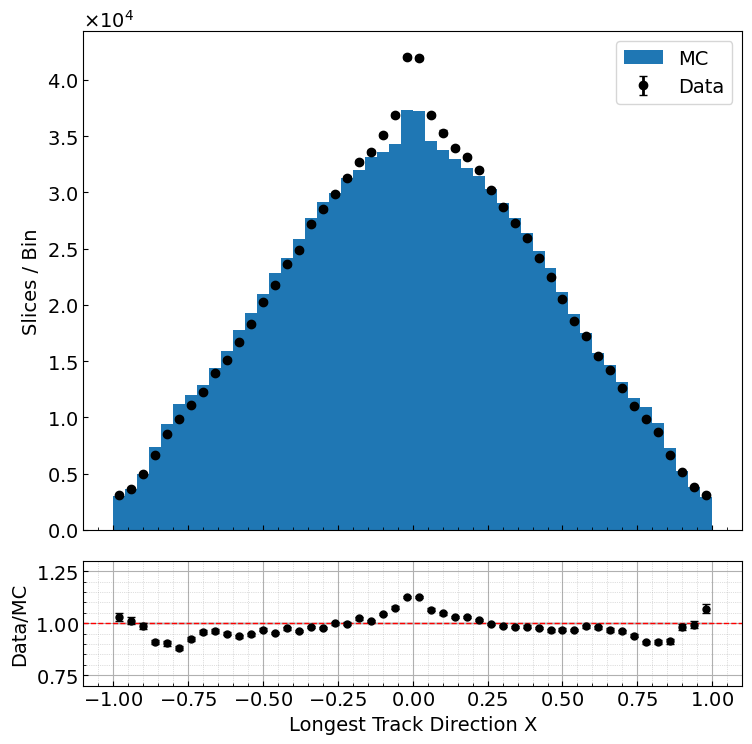

In [9]:
n_data = np.array(n_data_dict["vertex_in_fv"]["x"]).sum(axis=0)
n_mc = np.array(n_mc_dict["vertex_in_fv"]["x"]).sum(axis=0)
tot_data_pot = n_data_dict["tot_gates"]
tot_mc_pot = n_mc_dict["tot_gates"]
scale_mc = np.sum(n_data) / np.sum(n_mc)
n_mc = n_mc * scale_mc

fig, axs = plt.subplots(2, 1, figsize=(8.5, 8.5), 
                        sharex=True, gridspec_kw={'height_ratios': [4, 1]})
ax, ax_r = axs[0], axs[1]
fig.subplots_adjust(hspace=0.1)
ax_r.axhline(1.0, color='red', linestyle='--', linewidth=1)
ax_r.set_ylim(0.7, 1.3)
ax_r.set_ylabel("Data/MC")
ax_r.grid(True)
ax_r.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
ax_r.minorticks_on()
ax_r.set_xlabel("Longest Track Direction X")

bins = np.linspace(-1,1,51)
bin_centers = (bins[:-1] + bins[1:]) / 2
# n_mc, _ = np.histogram(var_mc, weights=intime_trk_df_longest.gates_weight, bins=bins)
# n_data, _ = np.histogram(var_data, bins=bins)
ax.hist(bin_centers, weights=n_mc, bins=bins, label="MC")
ax.errorbar(bin_centers, n_data, yerr=np.sqrt(n_data), fmt='o', color='k', capsize=3, label="Data")
ax.set_ylabel("Slices / Bin")
ax.legend()


mc_stat_err = np.sqrt(n_mc)
mc_stat_err_frac = mc_stat_err / n_mc
mc_content_ratio = n_mc / n_mc # dummy
mc_stat_err_ratio = mc_stat_err_frac / n_mc
ax_r.bar(
    bin_centers,
    2*mc_stat_err_ratio,
    width=np.diff(bins),
    bottom=mc_content_ratio - mc_stat_err_ratio,
    facecolor='none',
    edgecolor='dimgray',
    hatch='xxx',
    # linewidth=0.0,
    label='Syst. Unc.'
)

data_ratio = n_data / n_mc
data_eylow, data_eyhigh = return_data_stat_err(n_data)
data_ratio_eylow = data_eylow / n_mc
data_ratio_eyhigh = data_eyhigh / n_mc
data_ratio = np.nan_to_num(data_ratio, nan=-999.)
data_ratio_eylow = np.nan_to_num(data_ratio_eylow, nan=0.)
data_ratio_eyhigh = np.nan_to_num(data_ratio_eyhigh, nan=0.)
ax_r.errorbar(bin_centers, data_ratio, 
                yerr=np.vstack((data_ratio_eylow, data_ratio_eyhigh)),
                fmt='o', color='black',
                markersize=5, capsize=3, linewidth=1.5)
ax_r.fill_between(bin_centers, data_ratio_eylow, data_ratio_eyhigh, alpha=0.5)

plt.savefig("/exp/sbnd/data/users/munjung/plots/numucc1p0pi/cosmic_normalization/sbnd-cosmics-flux-normalization-dir_x.pdf", bbox_inches='tight')
plt.show();

# Compare with MicroBooNE

In [4]:
ret = get_ana_dfs(option="fake_data_test")
mc_hdr_df = ret['hdr']
mc_nu_df = ret['mcnu']
mc_evt_df = ret['evt']

pot_str = ret['pot_str']

Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/mcnu_0', '/split']
Reading file with tag aa, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/mcnu_0', '/split']
Reading file with tag ab, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/mcnu_0', '/split']
Reading file with tag ac, mc_n_split: 1
mc_tot_pot: 4.562e+19
mc_pot_scale: 1.000e+00


In [11]:
var_config = VariableConfig.all_events()
# var_config = VariableConfig.muon_momentum()